In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Load the dataset.
data_set = Path("/Users/bs01381/Documents/DataScience/house-price-prediction/data/USA_Housing.csv")

df = pd.read_csv(data_set)
print(f"Shape: {df.shape}")

Shape: (5000, 7)


In [3]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB


In [5]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
#make a data frame without address column, as it is not useful for our analysis.
address = df["Address"]
df_without_address = df.drop(columns=["Address"])

df_without_address.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
dtypes: float64(6)
memory usage: 234.5 KB


In [8]:
df_without_address.corr()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
Avg. Area Income,1.000000,-0.002007,-0.011032,0.019788,-0.016234,0.639734
Avg. Area House Age,-0.002007,1.000000,-0.009428,0.006149,-0.018743,0.452543
Avg. Area Number of Rooms,-0.011032,-0.009428,1.000000,0.462695,0.002040,0.335664
Avg. Area Number of Bedrooms,0.019788,0.006149,0.462695,1.000000,-0.022168,0.171071
Area Population,-0.016234,-0.018743,0.002040,-0.022168,1.000000,0.408556
Price,0.639734,0.452543,0.335664,0.171071,0.408556,1.000000


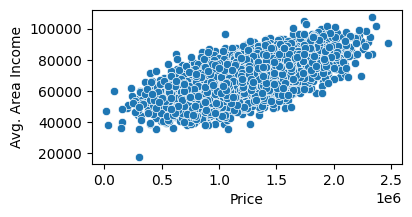

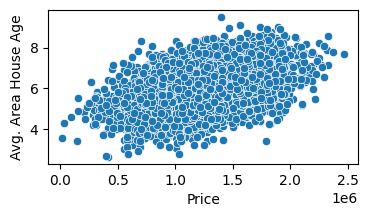

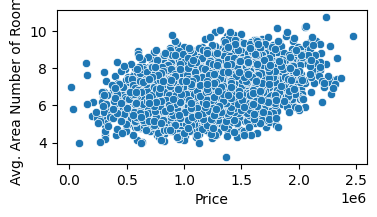

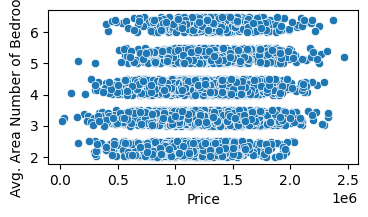

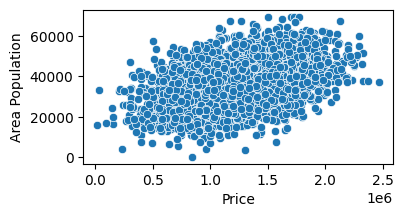

In [9]:
# make a graph between price and other all colloums
for col in df_without_address.columns:
    if col != "Price":
        plt.figure(figsize=(4, 2))
        sns.scatterplot(y=col, x="Price", data=df)
        plt.show()


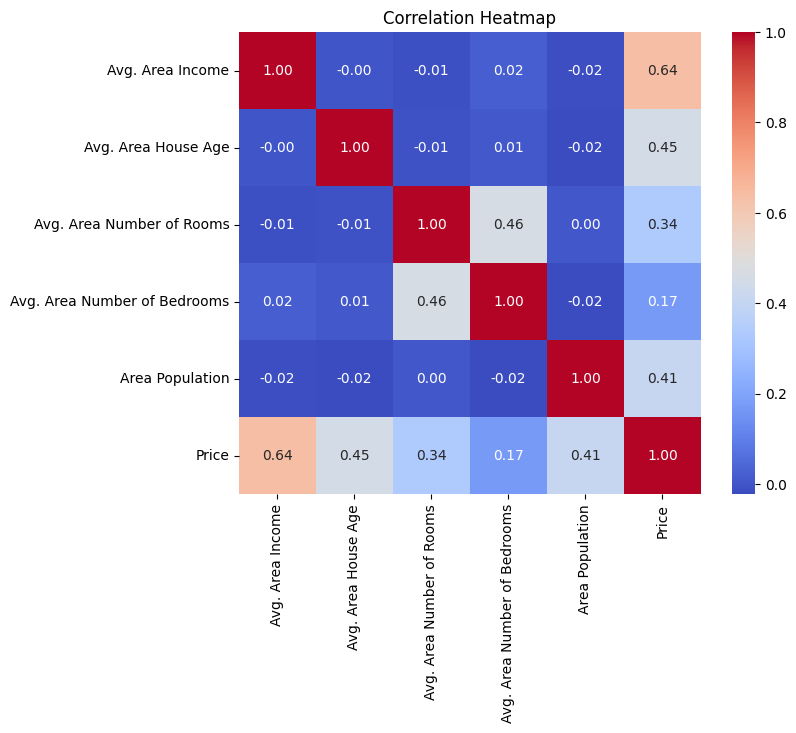

In [10]:

correlation_matrix = df_without_address.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.show()

## EDA Observations

### Most Important Features
Based on the correlation heatmap and scatter plots:
- **Avg. Area Income** has the strongest positive correlation with Price (~0.64), making it the most important predictor.
- **Avg. Area House Age** and **Avg. Area Number of Rooms** also show moderate positive correlations (~0.45–0.54).
- **Area Population** has a weaker but still positive correlation (~0.41).
- **Avg. Area Number of Bedrooms** has the weakest correlation with Price and may contribute least to prediction.

### Nature of Relationships
- The scatter plots show broadly **linear relationships** between Price and each numeric feature — as income, age, rooms, and population increase, price tends to increase.
- There is noticeable spread/variance around each trend, suggesting some noise, but no strong non-linear (e.g., quadratic or exponential) patterns are apparent.
- Features are largely **independent of each other** (low inter-feature correlations), which is ideal for linear models.

### Features Selected for Modeling
All five numeric features will be used:
1. Avg. Area Income
2. Avg. Area House Age
3. Avg. Area Number of Rooms
4. Avg. Area Number of Bedrooms
5. Area Population

The **Address** column is dropped as it is a free-text identifier with no direct predictive value in its raw form.

### Recommended Model Types
- **Linear Regression** — A strong baseline given the linear relationships observed. Interpretable and efficient.
- **Ridge / Lasso Regression** — Useful if multicollinearity exists or for feature selection (Lasso can shrink weak coefficients to zero).
